# Assignment 3 – VPAL Data Preprocessing Pipeline

This notebook builds a preprocessing pipeline for the VPAL Personality dataset using a Python class that handles data loading, cleaning, validation, and visualization.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/dsce/vpal/VPAL/Personality"
file_name = "PersonalityScoresVpal2.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
raw_path = os.path.join(base_path, file_name)
df_raw = pd.read_csv(raw_path)

print(df_raw.shape)
df_raw.head()

(76, 64)


,subj,sex,age,ACmotivation,ACprefcomplex,ACmetacog,ACbehint,ACcomplexexp,ACcontemporary,ACtemporal,BPphysical,BPverbal,BPanger,BPhostility,DSMDepressivity,DSMDistractibility,DSMEmotionLability,DSMHostility,DSMImpulsivity,DSMManipulativeness,DSMRigidPerfection,DSMRiskTaking,DSMWithdrawl,EmpathicConcern,PerspectiveTaking,NeedCognition,NPI16,PosAffect,NegAffect,selfN1,selfN2,selfN3,selfN4,selfN5,selfN6,selfE1,selfE2,selfE3,selfE4,selfE5,selfE6,selfO1,selfO2,selfO3,selfO4,selfO5,selfO6,selfA1,selfA2,selfA3,selfA4,selfA5,selfA6,selfC1,selfC2,selfC3,selfC4,selfC5,selfC6,selfN,selfE,selfO,selfA,selfC
0,102,M,21,17,16,17,13,18,18,13,42,18,17,23,21,23,17,19,23,16,20,62,19,21,25,50,45,45,25,20,19,24,22,30,17,28,25,17,27,24,32,36,34,35,34,37,32,24,21,25,25,21,25,25,22,26,22,31,17,132,153,208,141,143
1,103,F,19,15,14,16,14,15,14,17,12,9,11,10,23,25,18,15,17,17,26,39,15,31,30,46,47,46,19,23,14,19,20,25,18,36,36,24,30,32,35,26,30,29,26,27,28,37,27,36,33,31,34,27,29,29,30,25,25,119,193,166,198,165
2,104,M,18,16,16,16,17,14,19,15,41,15,19,14,28,18,23,24,19,15,26,60,15,31,32,48,51,49,22,23,13,19,26,26,20,37,35,29,28,34,35,34,29,34,31,34,36,33,32,38,33,32,34,30,30,36,31,32,23,127,198,198,202,182
3,105,F,20,12,16,14,15,15,17,13,10,11,12,11,18,24,22,18,13,12,26,51,14,26,28,49,47,38,14,21,21,19,24,28,29,30,26,23,24,30,31,24,37,37,34,31,36,28,31,26,28,25,30,31,28,33,27,25,23,142,164,199,168,167
4,106,M,22,14,20,12,13,15,16,18,34,13,10,17,23,43,14,21,22,12,18,56,43,12,19,34,40,25,15,14,17,19,17,29,16,24,13,15,14,28,14,29,34,22,32,23,37,10,20,29,30,34,25,22,13,20,22,19,14,112,108,177,148,110


In [6]:
df_raw.dtypes

,0
subj,int64
sex,object
age,int64
ACmotivation,int64
ACprefcomplex,int64
...,...
selfN,int64
selfE,int64
selfO,int64
selfA,int64


## Data Overview

The dataset has [76 rows, 64 columns]. Each row represents one VPAL participant and their personality scores. The columns include participant IDs and various personality metrics. I will use this table to build a preprocessing pipeline that loads, cleans, validates and visualizes the data.

In [7]:
df_raw = pd.read_csv(os.path.join(base_path, file_name))
df_raw.head()
df_raw.dtypes

,0
subj,int64
sex,object
age,int64
ACmotivation,int64
ACprefcomplex,int64
...,...
selfN,int64
selfE,int64
selfO,int64
selfA,int64


In [8]:
class VPALPreprocessor:
    def __init__(self, base_path, filename):
        self.base_path = base_path
        self.filename = filename
        self.df = None
        self.clean_df = None

    def load_data(self):
        path = os.path.join(self.base_path, self.filename)
        self.df = pd.read_csv(path)
        return self.df

    def clean_data(self):
        if self.df is None:
            raise ValueError("Call load_data first.")
        df = self.df.copy()
        df.columns = [c.strip() for c in df.columns]

        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

        for col in numeric_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        df = df.drop_duplicates()
        self.clean_df = df
        return self.clean_df

    def validate_data(self):
        if self.clean_df is None:
            raise ValueError("Call clean_data first.")
        df = self.clean_df
        report = {}
        report["shape"] = df.shape
        report["missing_fraction"] = df.isna().mean()
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        report["describe"] = df[numeric_cols].describe()
        report["negative_counts"] = (df[numeric_cols] < 0).sum()
        upper = df[numeric_cols].quantile(0.99)
        report["outlier_counts"] = (df[numeric_cols] > upper).sum()
        return report

    def visualize_data(self, max_plots=6):
        if self.clean_df is None:
            raise ValueError("Call clean_data first.")
        df = self.clean_df
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

        for col in numeric_cols[:max_plots]:
            plt.figure(figsize=(6, 4))
            sns.histplot(df[col].dropna(), bins=20)
            plt.title(f"Distribution of {col}")
            plt.xlabel(col)
            plt.ylabel("Count")
            plt.show()

        for col in cat_cols[:2]:
            plt.figure(figsize=(8, 4))
            df[col].value_counts().plot(kind="bar")
            plt.title(f"Counts of {col}")
            plt.xlabel(col)
            plt.ylabel("Count")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()

## Preprocessing Pipeline Class

I built a `VPALPreprocessor` class with four methods:

1. **load_data** – reads the CSV into a pandas DataFrame
2. **clean_data** – strips whitespace from column names, converts numeric columns, and removes duplicate rows
3. **validate_data** – checks for missing values, negative values, and potential outliers above the 99th percentile
4. **visualize_data** – generates histograms for numeric variables and bar charts for categorical variables

## Step 1: Data Loading

I loaded the PersonalityScoresVpal2.csv file into a DataFrame. Each row corresponds to one participant and includes their personality trait scores.

In [9]:
prep = VPALPreprocessor(base_path=base_path, filename=file_name)

df_loaded = prep.load_data()
df_loaded.head()

,subj,sex,age,ACmotivation,ACprefcomplex,ACmetacog,ACbehint,ACcomplexexp,ACcontemporary,ACtemporal,BPphysical,BPverbal,BPanger,BPhostility,DSMDepressivity,DSMDistractibility,DSMEmotionLability,DSMHostility,DSMImpulsivity,DSMManipulativeness,DSMRigidPerfection,DSMRiskTaking,DSMWithdrawl,EmpathicConcern,PerspectiveTaking,NeedCognition,NPI16,PosAffect,NegAffect,selfN1,selfN2,selfN3,selfN4,selfN5,selfN6,selfE1,selfE2,selfE3,selfE4,selfE5,selfE6,selfO1,selfO2,selfO3,selfO4,selfO5,selfO6,selfA1,selfA2,selfA3,selfA4,selfA5,selfA6,selfC1,selfC2,selfC3,selfC4,selfC5,selfC6,selfN,selfE,selfO,selfA,selfC
0,102,M,21,17,16,17,13,18,18,13,42,18,17,23,21,23,17,19,23,16,20,62,19,21,25,50,45,45,25,20,19,24,22,30,17,28,25,17,27,24,32,36,34,35,34,37,32,24,21,25,25,21,25,25,22,26,22,31,17,132,153,208,141,143
1,103,F,19,15,14,16,14,15,14,17,12,9,11,10,23,25,18,15,17,17,26,39,15,31,30,46,47,46,19,23,14,19,20,25,18,36,36,24,30,32,35,26,30,29,26,27,28,37,27,36,33,31,34,27,29,29,30,25,25,119,193,166,198,165
2,104,M,18,16,16,16,17,14,19,15,41,15,19,14,28,18,23,24,19,15,26,60,15,31,32,48,51,49,22,23,13,19,26,26,20,37,35,29,28,34,35,34,29,34,31,34,36,33,32,38,33,32,34,30,30,36,31,32,23,127,198,198,202,182
3,105,F,20,12,16,14,15,15,17,13,10,11,12,11,18,24,22,18,13,12,26,51,14,26,28,49,47,38,14,21,21,19,24,28,29,30,26,23,24,30,31,24,37,37,34,31,36,28,31,26,28,25,30,31,28,33,27,25,23,142,164,199,168,167
4,106,M,22,14,20,12,13,15,16,18,34,13,10,17,23,43,14,21,22,12,18,56,43,12,19,34,40,25,15,14,17,19,17,29,16,24,13,15,14,28,14,29,34,22,32,23,37,10,20,29,30,34,25,22,13,20,22,19,14,112,108,177,148,110


## Step 2: Data Cleaning

The cleaning step strips extra whitespace from column names, ensures numeric columns are properly typed, and removes any duplicate rows. After cleaning, the dataset has [76] rows and [64] columns.

After running my cleaning function the dataset still has 76 rows and 64 columns. This tells me there were no exact duplicate participants to remove and the original VPAL personality file is already fairly clean. The main effect of this step is that column names are standardized and all personality scores are stored as numeric types, which makes later analysis easier.

In [10]:
df_clean = prep.clean_data()
print(f"Shape after cleaning: {df_clean.shape}")
df_clean.head()

Shape after cleaning: (76, 64)


,subj,sex,age,ACmotivation,ACprefcomplex,ACmetacog,ACbehint,ACcomplexexp,ACcontemporary,ACtemporal,BPphysical,BPverbal,BPanger,BPhostility,DSMDepressivity,DSMDistractibility,DSMEmotionLability,DSMHostility,DSMImpulsivity,DSMManipulativeness,DSMRigidPerfection,DSMRiskTaking,DSMWithdrawl,EmpathicConcern,PerspectiveTaking,NeedCognition,NPI16,PosAffect,NegAffect,selfN1,selfN2,selfN3,selfN4,selfN5,selfN6,selfE1,selfE2,selfE3,selfE4,selfE5,selfE6,selfO1,selfO2,selfO3,selfO4,selfO5,selfO6,selfA1,selfA2,selfA3,selfA4,selfA5,selfA6,selfC1,selfC2,selfC3,selfC4,selfC5,selfC6,selfN,selfE,selfO,selfA,selfC
0,102,M,21,17,16,17,13,18,18,13,42,18,17,23,21,23,17,19,23,16,20,62,19,21,25,50,45,45,25,20,19,24,22,30,17,28,25,17,27,24,32,36,34,35,34,37,32,24,21,25,25,21,25,25,22,26,22,31,17,132,153,208,141,143
1,103,F,19,15,14,16,14,15,14,17,12,9,11,10,23,25,18,15,17,17,26,39,15,31,30,46,47,46,19,23,14,19,20,25,18,36,36,24,30,32,35,26,30,29,26,27,28,37,27,36,33,31,34,27,29,29,30,25,25,119,193,166,198,165
2,104,M,18,16,16,16,17,14,19,15,41,15,19,14,28,18,23,24,19,15,26,60,15,31,32,48,51,49,22,23,13,19,26,26,20,37,35,29,28,34,35,34,29,34,31,34,36,33,32,38,33,32,34,30,30,36,31,32,23,127,198,198,202,182
3,105,F,20,12,16,14,15,15,17,13,10,11,12,11,18,24,22,18,13,12,26,51,14,26,28,49,47,38,14,21,21,19,24,28,29,30,26,23,24,30,31,24,37,37,34,31,36,28,31,26,28,25,30,31,28,33,27,25,23,142,164,199,168,167
4,106,M,22,14,20,12,13,15,16,18,34,13,10,17,23,43,14,21,22,12,18,56,43,12,19,34,40,25,15,14,17,19,17,29,16,24,13,15,14,28,14,29,34,22,32,23,37,10,20,29,30,34,25,22,13,20,22,19,14,112,108,177,148,110


In the validation step I looked at the overall shape, missing values, negative values and potential outliers for the VPAL personality dataset. The cleaned table has 76 rows and 64 columns and all columns have a missing value fraction of 0 so there are no NaNs to handle. None of the numeric columns contain negative values, which is what I expect for personality scales that should be non‑negative.

When I counted values above the 99th percentile, almost every numeric column had exactly one value flagged. With only 76 participants this is basically the extreme high score for each trait rather than a data error. For this assignment I treat these as natural high scoring participants rather than removing them, but it is useful to know that the distributions have a single very high value on most traits.

In [11]:
report = prep.validate_data()

print("Dataset shape:", report["shape"])
print("\nMissing value fractions:")
print(report["missing_fraction"])
print("\nNegative value counts:")
print(report["negative_counts"])
print("\nOutlier counts (above 99th percentile):")
print(report["outlier_counts"])

Dataset shape: (76, 64)

Missing value fractions:
subj             0.0
sex              0.0
age              0.0
ACmotivation     0.0
ACprefcomplex    0.0
                ... 
selfN            0.0
selfE            0.0
selfO            0.0
selfA            0.0
selfC            0.0
Length: 64, dtype: float64

Negative value counts:
subj             0
age              0
ACmotivation     0
ACprefcomplex    0
ACmetacog        0
                ..
selfN            0
selfE            0
selfO            0
selfA            0
selfC            0
Length: 63, dtype: int64

Outlier counts (above 99th percentile):
subj             1
age              1
ACmotivation     1
ACprefcomplex    1
ACmetacog        0
                ..
selfN            1
selfE            1
selfO            1
selfA            1
selfC            1
Length: 63, dtype: int64


### **Visualization step**

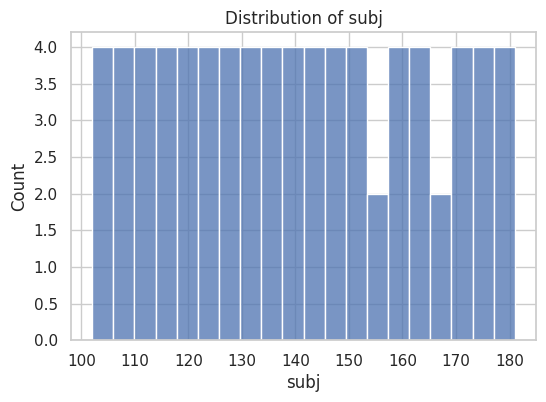

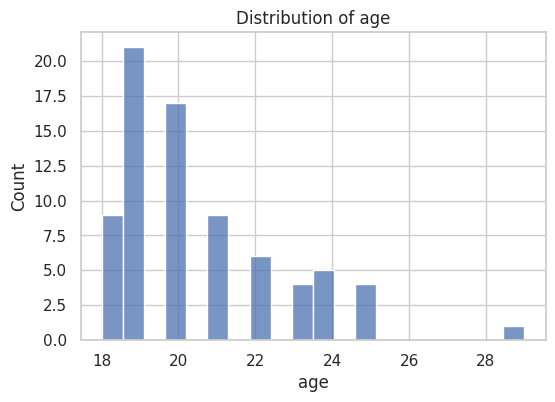

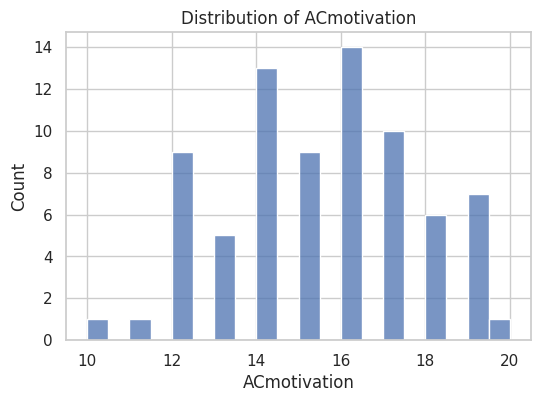

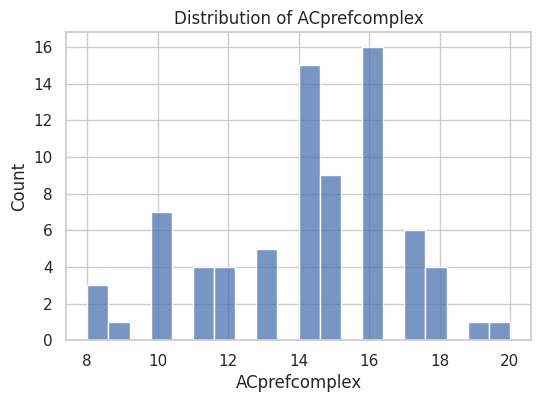

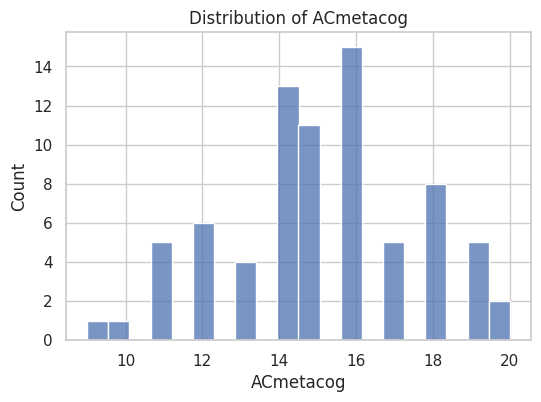

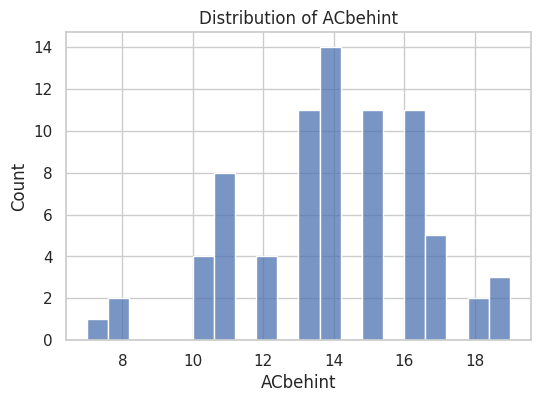

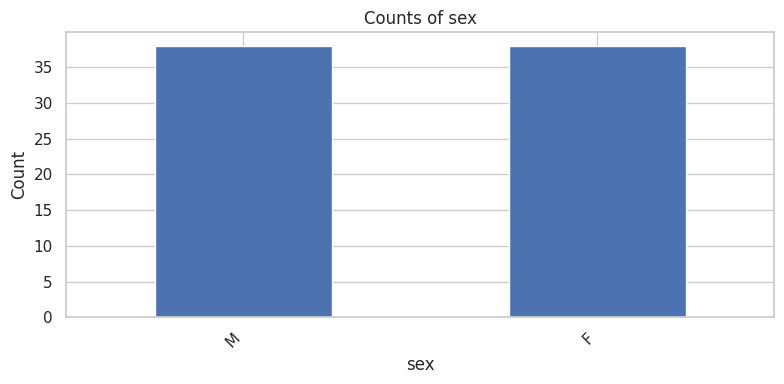

In [12]:
prep.visualize_data()

In this step I looked at a few basic plots to get a feel for the VPAL personality data. The bar chart for `sex` shows that the sample is almost perfectly balanced between male and female participants so there is no obvious gender imbalance in this dataset. The histograms for the AC scales (`ACbehint`, `ACmetacog`, `ACprefcomplex`, `ACmotivation`) are roughly bell shaped and centered around the middle of each scale with a handful of higher scores but no huge gaps or strange spikes. The age distribution is tightly clustered between about 18 and 24 with one older participant in their late twenties, which fits the idea that this study mostly recruited college age students. The `subj` plot just confirms that participant IDs are evenly spread across a range of values and do not carry any interesting structure by themselves.

Overall, this preprocessing pipeline gives me a clean and well understood version of the VPAL personality dataset to work with. The final table has 76 participants and 64 variables with no missing values or negative scores, so I do not need to do any heavy imputation or filtering at this stage. The validation step mainly highlighted a few natural high end scores on the personality traits rather than obvious data errors, which I decided to keep as genuine extreme values. The visualizations helped me confirm that most traits are roughly bell shaped, the sample is balanced by sex, and the ages are concentrated around typical college years.